<a href="https://colab.research.google.com/github/ptsouth97/AASTeX52/blob/master/OR_And.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Imports

In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import lombscargle

plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["font.size"] = 12

#Load Data


*   Load spreadsheets and convert into dataframes



In [3]:

file1 = "2026-06-19 OR And FINAL.xlsx"
file2 = "2026-06-24 OR And FINAL.xlsx"
file3 = "2026-07-11 OR And-1.xlsx"
file4 = "2026-07-26 OR And-2.xlsx"
file5 = "2026-08-20 OR And-1.xlsx"

df1 = pd.read_excel(file1)
df2 = pd.read_excel(file2)
df3 = pd.read_excel(file3)
df4 = pd.read_excel(file4)
df5 = pd.read_excel(file5)

#Build Differential Photometry


*   Gets the photometry values from each dataframe



In [4]:
def extract_diffmag(df):

    jd = df.iloc[:,0].astype(float).values

    target = df.iloc[:,2].astype(float).values

    comp143 = df.iloc[:,3].astype(float).values
    comp148 = df.iloc[:,4].astype(float).values
    comp152 = df.iloc[:,5].astype(float).values

    ensemble = (comp143 + comp148 + comp152) / 3.0

    diffmag = target - ensemble

    return jd, diffmag


jd1, dmag1 = extract_diffmag(df1)
jd2, dmag2 = extract_diffmag(df2)
jd3, dmag3 = extract_diffmag(df3)
jd4, dmag4 = extract_diffmag(df4)
jd5, dmag5 = extract_diffmag(df5)

#Combine Data

In [5]:
jd = np.concatenate([jd1, jd2, jd3, jd4, jd5])

dmag = np.concatenate([dmag1, dmag2, dmag3, dmag4, dmag5])

sort_idx = np.argsort(jd)

jd = jd[sort_idx]
dmag = dmag[sort_idx]

jd0 = jd.min()

time = jd - jd0

signal = dmag - np.mean(dmag)

print("Number of observations:", len(signal))

Number of observations: 576


#Lomb–Scargle Primary Period Search


*   Designed for:
*   Unevenly spaced observations
*   Missing data
*   Astronomical time-series data
*   At each tested frequency the algorithm fits something approximating a sine wave
*   And asks, "How much of the observed variability can be explained by this periodic signal?"
*   The better the fit, the larger the power
*   Tells us:
*   What periods are present
*   How strong they are
*   Which periods are preferred
*   But not:
*   Whether the period is orbital
*   Whether the period is a superhump
*   Whether multiple periods exist










In [6]:
frequencies = np.linspace(
    2,
    20,
    150000
)
'''frequencies = np.linspace(
    7.8,
    8.2,
    50000
  )'''
angular_freq = 2*np.pi*frequencies

power = lombscargle(
    time,
    signal,
    angular_freq
)

periods = 24.0 / frequencies

best_index = np.argmax(power)

best_period = periods[best_index]

print(f"Best Period = {best_period:.6f} hr")

Best Period = 3.006072 hr


#Plot Periodogram

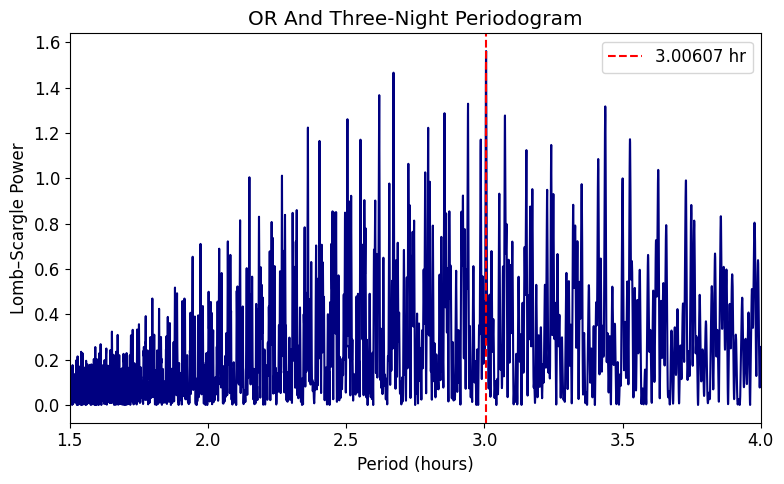

In [7]:
plt.figure(figsize=(8,5))

plt.plot(
    periods,
    power,
    color="navy"
)

plt.axvline(
    best_period,
    color="red",
    linestyle="--",
    label=f"{best_period:.5f} hr"
)

plt.xlim(1.5,4)

plt.xlabel("Period (hours)")
plt.ylabel("Lomb–Scargle Power")

plt.title(
    "OR And Three-Night Periodogram"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "OR_And_3night_periodogram.png",
    dpi=300
)

plt.show()

#Bootstrap Uncertainty


*   If I had observed OR And again under slightly different circumstances, how much might the measured period have changed?
*   It's a method for estimating the uncertainty directly from your data, rather than guessing from the width of a periodogram peak
*   A bootstrap sample randomly selects from the dataset with replacement
*   So some observations will be repeated, and some omitted.
*   Then we recreate the light curve
*   Run a Lomb-Scargle period search
*   Record the best period
*   If the histogram is centered near the original period, the result is robust
*   Multiple peaks indicates a weaker result



In [ ]:
import numpy as np
from scipy.signal import lombscargle
from tqdm import tqdm

N_BOOT = 1000

boot_periods = []

for _ in tqdm(range(N_BOOT)):

    idx = np.random.randint(
        0,
        len(time),
        len(time)
    )

    t_boot = time[idx]
    s_boot = signal[idx]

    sort_idx = np.argsort(t_boot)

    t_boot = t_boot[sort_idx]
    s_boot = s_boot[sort_idx]

    power_boot = lombscargle(
        t_boot,
        s_boot - np.mean(s_boot),
        angular_freq
    )

    best_idx = np.argmax(power_boot)

    boot_periods.append(
        periods[best_idx]
    )

boot_periods = np.array(boot_periods)

p16 = np.percentile(
    boot_periods,
    16
)

p50 = np.percentile(
    boot_periods,
    50
)

p84 = np.percentile(
    boot_periods,
    84
)

print(
    f"Period = {p50:.6f} hr"
)

print(
    f"+{p84-p50:.6f} hr"
)

print(
    f"-{p50-p16:.6f} hr"
)

print()

print(
    f"Period = {p50/24:.6f} d"
)

print(
    f"+{(p84-p50)/24:.6f} d"
)

print(
    f"-{(p50-p16)/24:.6f} d"
)

100%|██████████| 1000/1000 [2:21:37<00:00,  8.50s/it]

Period = 3.006072 hr
+0.000090 hr
-0.000090 hr

Period = 0.125253 d
+0.000004 d
-0.000004 d


#Visualize the distribution

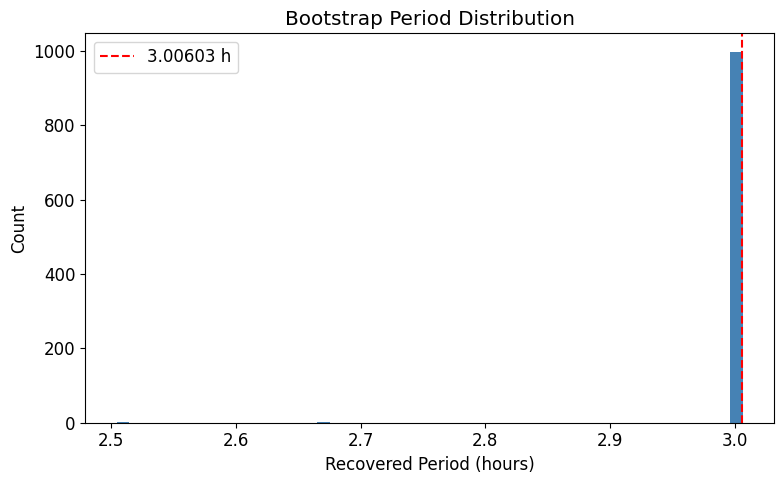

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    boot_periods,
    bins=50,
    color="steelblue"
)

plt.axvline(
    median_period,
    color="red",
    linestyle="--",
    label=f"{median_period:.5f} h"
)

plt.xlabel("Recovered Period (hours)")
plt.ylabel("Count")

plt.title(
    "Bootstrap Period Distribution"
)

plt.legend()

plt.tight_layout()
plt.show()

#Phase Fold Data

In [8]:
P_days = best_period / 24.0

phase = ((jd - jd.min()) % P_days) / P_days

#Plot Raw Phase Curve

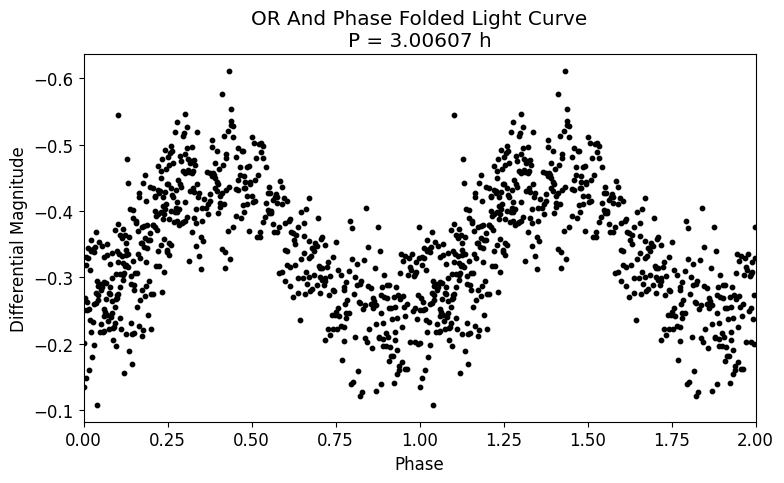

In [9]:
plt.figure(figsize=(8,5))

plt.scatter(
    np.r_[phase, phase + 1],
    np.r_[dmag, dmag],
    s=10,
    color="black"
)

plt.gca().invert_yaxis()

plt.xlim(0,2)

plt.xlabel("Phase")
plt.ylabel("Differential Magnitude")

plt.title(
    f"OR And Phase Folded Light Curve\nP = {best_period:.5f} h"
)

plt.tight_layout()

plt.savefig(
    "OR_And_phase_raw.png",
    dpi=300
)

plt.show()

#Create Phase Bins


*   Every observation falling into a given phase interval is binned together to reduce the noise.
*   The mean and standard deviation are calculated for each bin.



In [10]:
bins = np.linspace(0,1,21)

centers = (
    bins[:-1] + bins[1:]
) / 2

means = []
errs = []

for i in range(len(bins)-1):

    m = (
        (phase >= bins[i]) &
        (phase < bins[i+1])
    )

    means.append(
        np.mean(dmag[m])
    )

    errs.append(
        np.std(dmag[m], ddof=1)
    )

means = np.array(means)
errs = np.array(errs)

#Publication-Quality Phase Plot


*   Shows the phase plot with the binned data and error bars



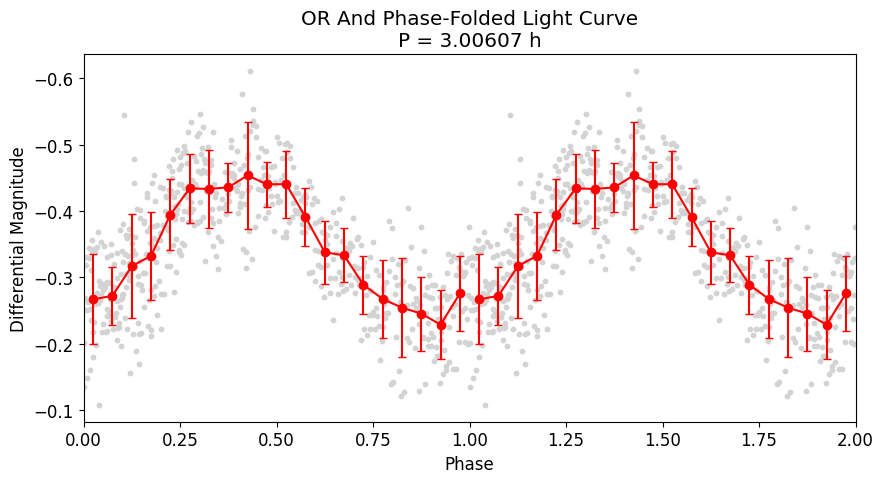

In [11]:
plt.figure(figsize=(9,5))

plt.scatter(
    np.r_[phase, phase+1],
    np.r_[dmag, dmag],
    s=10,
    color="lightgray"
)

plt.errorbar(
    centers,
    means,
    yerr=errs,
    fmt='o-',
    color='red',
    capsize=3,
    lw=1.5
)

plt.errorbar(
    centers+1,
    means,
    yerr=errs,
    fmt='o-',
    color='red',
    capsize=3,
    lw=1.5
)

plt.gca().invert_yaxis()

plt.xlim(0,2)

plt.xlabel("Phase")
plt.ylabel("Differential Magnitude")

plt.title(
    f"OR And Phase-Folded Light Curve\nP = {best_period:.5f} h"
)

plt.tight_layout()

plt.savefig(
    "OR_And_phase_binned.png",
    dpi=300
)

plt.show()

#Print Top Peaks

In [12]:
top_idx = np.argsort(power)[-20:][::-1]

print("Top Periodogram Peaks")

for i in top_idx[:10]:

    print(
        f"{periods[i]:.6f} hr  "
        f"Power = {power[i]:.5f}"
    )

Top Periodogram Peaks
3.006072 hr  Power = 1.56216
3.006027 hr  Power = 1.56212
3.006117 hr  Power = 1.56130
3.005982 hr  Power = 1.56116
3.006163 hr  Power = 1.55954
3.005937 hr  Power = 1.55930
3.006208 hr  Power = 1.55687
3.005892 hr  Power = 1.55655
3.006253 hr  Power = 1.55330
3.005846 hr  Power = 1.55289


#Define the best primary period

In [13]:
best_period_days = P_days

#Pre-whitening Analysis


*   A normal Lomb-Scargle periodogram often finds only the strongest period
*   Pre-whitening works like:
*   Find the strongest period
*   Fit it
*   Subtract it
*   Recompute periodogram
*   Repeat if necessary
*   This lets you uncover multiple clocks in the same system
*   E.g., the stronger orbital signal can hide the superhump
*   It's like subtracting the loud trumpet sound out of an orchestra
*   It's called pre-whitening because you're removing ("whitening out") the strongest known signal before searching for weaker ones



In [14]:
import numpy as np
from scipy.optimize import curve_fit
from astropy.timeseries import LombScargle

best_freq = 1.0 / best_period_days

def sinusoid(t, A, B, C):
    w = 2*np.pi*best_freq
    return (
        A*np.cos(w*t)
        + B*np.sin(w*t)
        + C
    )

popt, _ = curve_fit(
    sinusoid,
    time,
    signal
)

model = sinusoid(
    time,
    *popt
)

residuals = signal - model

#Compute a residual periodogram


*   A residual is the observed data minus the model
*   Specifically, the differential magnitude minus the model sine wave for a particular period
*   So, a residual periodogram is simply a second Lomb–Scargle periodogram computed from the residuals
*   If there's only one period, the residuals should be noise



In [17]:
freq2, power2 = LombScargle(
    time,
    residuals
).autopower(
    minimum_frequency=2,
    maximum_frequency=20
)

period2 = 24.0 / freq2

#Plot residual periodogram

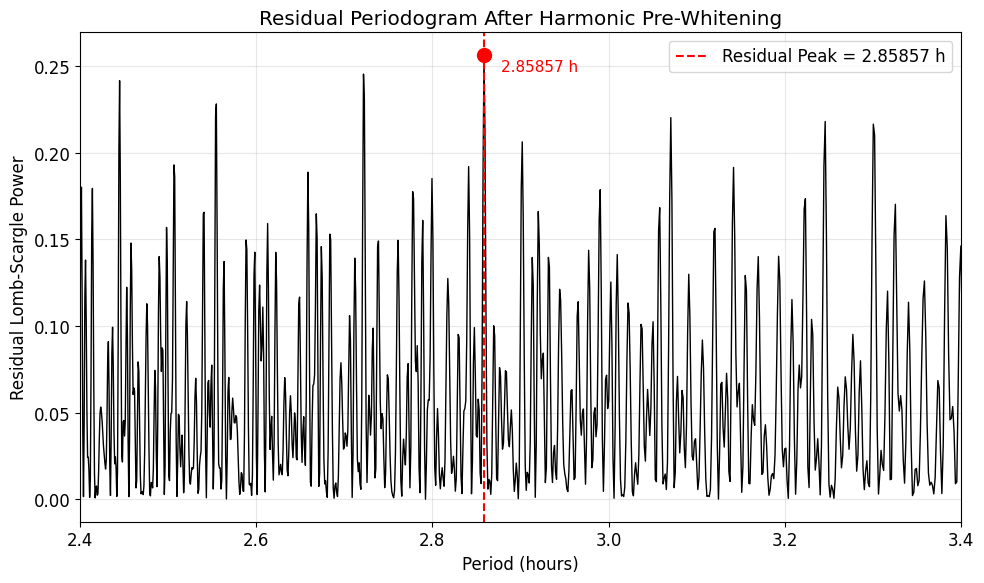

In [27]:
plt.figure(figsize=(10,6))

plt.plot(
    period2,
    power2,
    color='black',
    linewidth=1
)

plt.xlim(2.4,3.4)

plt.xlabel("Period (hours)")
plt.ylabel("Residual Lomb-Scargle Power")

plt.title("Residual Periodogram After Harmonic Pre-Whitening"
)

plt.grid(alpha=0.3)

plt.axvline(
    2.85857,
    color='red',
    linestyle='--',
    label='Residual Peak = 2.85857 h'
)

peak_period = 2.85857

plt.annotate(
    "2.85857 h",
    (peak_period, power2[peak_idx]),
    xytext=(12,-12),
    textcoords="offset points",
    color="red",
    fontsize=11
)

peak_idx = np.argmin(
    np.abs(period2 - peak_period)
)

plt.scatter(
    peak_period,
    power2[peak_idx],
    color='red',
    s=100,
    zorder=10
)
plt.legend()
plt.tight_layout()
plt.show()

#Find the strongest residual peaks

In [ ]:
top_idx = np.argsort(power2)[-20:][::-1]

print("Residual Periodogram Peaks")

for i in top_idx[:20]:
    print(
        f"{period2[i]:.6f} hr   "
        f"Power={power2[i]:.6f}"
    )

Residual Periodogram Peaks
2.858573 hr   Power=0.256463
2.721740 hr   Power=0.245209
2.444806 hr   Power=0.241409
2.722735 hr   Power=0.230711
2.554649 hr   Power=0.228008
2.553773 hr   Power=0.221375
3.070692 hr   Power=0.220134
3.245991 hr   Power=0.217904
3.300649 hr   Power=0.216336
2.859670 hr   Power=0.212573
3.302112 hr   Power=0.210011
2.902007 hr   Power=0.206142
2.269737 hr   Power=0.204178
2.444004 hr   Power=0.201885
2.308425 hr   Power=0.201088
3.828218 hr   Power=0.198428
2.506508 hr   Power=0.192862
3.244577 hr   Power=0.192262
2.841127 hr   Power=0.191876
3.141932 hr   Power=0.191423


#Build the harmonic model


*   The goal is to remove not only the fundamental frequency signal, but also its harmonics.
*   Harmonics are pure sine and cosine wave components whose frequencies are integer multiples of a repeating signal's fundamental frequency
*   If the light curve is non-sinusoidal, a single-sine fit leaves residual power at these related frequencies that can masquerade as secondary periods



In [ ]:
import numpy as np

best_period_days = 0.1252524
f0 = 1.0 / best_period_days
w = 2 * np.pi * f0

X = np.column_stack([
    np.sin(w*time),
    np.cos(w*time),

    np.sin(2*w*time),
    np.cos(2*w*time),

    np.sin(3*w*time),
    np.cos(3*w*time),

    np.ones_like(time)
])

#Fit the model

In [ ]:
coeffs, _, _, _ = np.linalg.lstsq(
    X,
    signal,
    rcond=None
)

#Generate fitted waveform

In [ ]:
model = X @ coeffs

#Compute residuals

In [ ]:
residuals = signal - model

#Compute residual periodogram

In [ ]:
from astropy.timeseries import LombScargle

freq2, power2 = LombScargle(
    time,
    residuals
).autopower(
    minimum_frequency=2,
    maximum_frequency=20,
    samples_per_peak=10
)

period2 = 24.0 / freq2

#Identify strongest residual peaks

In [ ]:
from scipy.signal import find_peaks

peak_idx, _ = find_peaks(power2)

peak_periods = period2[peak_idx]
peak_powers  = power2[peak_idx]

order = np.argsort(peak_powers)[::-1]

print("Residual Independent Peaks")

for i in order[:20]:
    print(
        f"{peak_periods[i]:.6f} hr   "
        f"Power={peak_powers[i]:.6f}"
    )

Residual Independent Peaks
2.858573 hr   Power=0.254649
2.722237 hr   Power=0.250963
3.301380 hr   Power=0.237432
2.444806 hr   Power=0.229949
2.554211 hr   Power=0.226636
3.070692 hr   Power=0.226507
3.245284 hr   Power=0.224412
3.828218 hr   Power=0.216227
2.901442 hr   Power=0.212471
3.141932 hr   Power=0.203565
3.939579 hr   Power=0.193239
2.778079 hr   Power=0.191766
2.841127 hr   Power=0.189747
3.615459 hr   Power=0.187180
2.506930 hr   Power=0.186842
2.308425 hr   Power=0.186495
3.222817 hr   Power=0.185828
3.504055 hr   Power=0.184880
2.269737 hr   Power=0.182780
3.383100 hr   Power=0.182420


#Secondary period

In [ ]:
secondary_period_days = 2.858573 / 24.0
secondary_period_hours = secondary_period_days * 24.0

phase2 = (
    (time % secondary_period_days)
    / secondary_period_days
)

#Plot secondary period

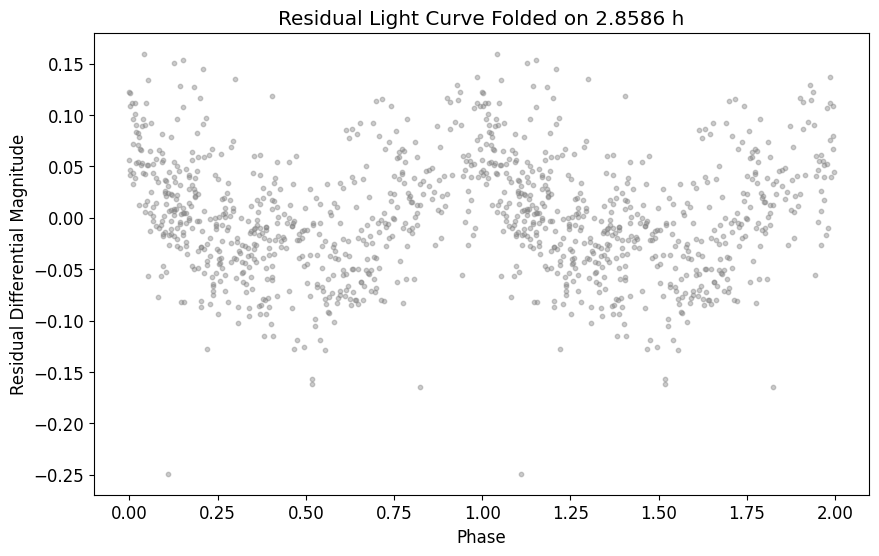

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(
    phase2,
    residuals,
    s=10,
    alpha=0.4,
    color="gray"
)

plt.scatter(
    phase2 + 1,
    residuals,
    s=10,
    alpha=0.4,
    color="gray"
)

plt.xlabel("Phase")
plt.ylabel("Residual Differential Magnitude")

plt.title(
    "Residual Light Curve Folded on 2.8586 h"
)

plt.show()

#Create secondary phase bins

In [ ]:
bins = np.linspace(0,1,21)

centers = (
    bins[:-1] + bins[1:]
) / 2

means = []
errs = []

for i in range(len(bins)-1):

    m = (
        (phase2 >= bins[i]) &
        (phase2 < bins[i+1])
    )

    means.append(
        np.mean(dmag[m])
    )

    errs.append(
        np.std(dmag[m], ddof=1)
    )

means = np.array(means)
errs = np.array(errs)

#Publication-Quality Secondary Phase Plot

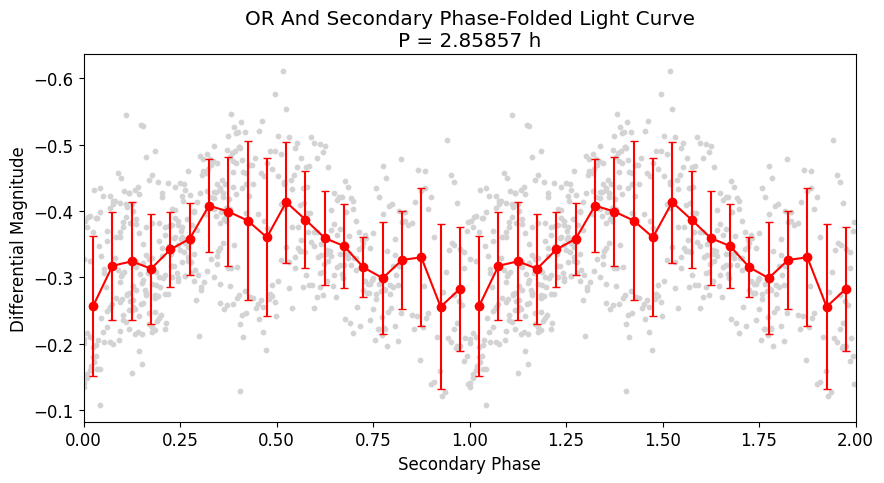

In [ ]:
plt.figure(figsize=(9,5))

plt.scatter(
    np.r_[phase2, phase2+1],
    np.r_[dmag, dmag],
    s=10,
    color="lightgray"
)

plt.errorbar(
    centers,
    means,
    yerr=errs,
    fmt='o-',
    color='red',
    capsize=3,
    lw=1.5
)

plt.errorbar(
    centers+1,
    means,
    yerr=errs,
    fmt='o-',
    color='red',
    capsize=3,
    lw=1.5
)

plt.gca().invert_yaxis()

plt.xlim(0,2)

plt.xlabel("Secondary Phase")
plt.ylabel("Differential Magnitude")

plt.title(
    f"OR And Secondary Phase-Folded Light Curve\nP = {secondary_period_hours:.5f} h"
)

plt.tight_layout()

plt.savefig(
    "OR_And_secondary_phase_binned.png",
    dpi=300
)

plt.show()